# 02 — Run Preprocessing

Apply background correction and noise reduction to prepare data for GMM segmentation.

In [1]:
# Import necessary libraries

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from pathlib import Path
import os

In [2]:
# Import custom modules for loading and preprocessing CT scan data
from research_ct.io.volume_loader import Load_Slice_Stack
from research_ct.preprocessing.visual.config import Preprocessing_Config
from research_ct.preprocessing.pipeline_gmm import Preprocess_For_Gmm
from research_ct.preprocessing.pipeline_visual import Preprocess_For_visual
from research_ct.visualization.histogram_diagnostics_viewer import (
    Plot_Histogram_Comparison,
    Plot_Slice_Histograms,
)

In [3]:
# Project directory and data paths
PROJECT_DIR = Path.cwd()

# Find project root directory
while not (PROJECT_DIR / "src").exists():
    PROJECT_DIR = PROJECT_DIR.parent

#Data path
# Load raw data
DATA_DIR = PROJECT_DIR / "data" 
RAW_DATA_DIR = DATA_DIR / "raw"
OUTPUT_DATA_DIR = DATA_DIR / "output"
FIGURES_DIR = OUTPUT_DATA_DIR / "figures"
DIAG_DIR = OUTPUT_DATA_DIR / "diagnostics"

# CHECK IF FIGURES_DIR EXISTS, IF NOT CREATE IT
if not FIGURES_DIR.exists():
    FIGURES_DIR.mkdir(parents=True, exist_ok=True)



In [4]:

Volume = Load_Slice_Stack(RAW_DATA_DIR, Pattern="*.tif*", Stop=201)
print(f"Loaded: {Volume.shape}")

[Load_Slice_Stack] 201 slices from c:\Users\ORSAdmin\Documents\Gabriel\research_ct\data\raw (range 0:201:1 of 201 total)
[Load_Slice_Stack] Volume: (201, 1734, 1705), range [26129.0, 60735.0]
Loaded: (201, 1734, 1705)


## Run pipeline:  Background correction and noise reduction

Beam hardering removal, gaussian statistical dsitribution correction and standardization. 

In [5]:
print("\nRunning revised preprocessing...")


PREPROCESSING_PARAMS = {
    "Air_Threshold_Percentile": 10.0,  # Generates ROI mask to exclude air noise
    "Noise_Sigma": 0.8,  # Preserves central limit theorem Gaussian shapes
    "Clip_Low_Percentile": 0.0,  # Calculated strictly on foreground ROI
    "Clip_High_Percentile": 99.9,  # Calculated strictly on foreground ROI
    "Bit_Depth": 32,  # User-selected depth: 32 (float), 16 (int), or 8 (int)
    "Verbose": True,
}

Processed_Volume, Diagnostics = Preprocess_For_Gmm(Volume, **PREPROCESSING_PARAMS)


Running revised preprocessing...
[Preprocess_GMM] Input: (201, 1734, 1705), Bit Depth: 32

[Step 1/4] Creating ROI Mask (threshold p=10.0)...
[Step 1/4] Done in 4.3s.

[Step 2/4] Noise reduction (sigma=0.8)...
[Step 2/4] Done in 12.2s.

[Step 3/4] 1D Extraction and Normalization (0.0-99.9 percentiles)...
[Step 3/4] Done in 9.3s.

[Step 4/4] 3D Tensor Reconstruction...
[Step 4/4] Done in 1.4s.

[Diagnostics] Assessing GMM readiness...
[Diagnostics] Modes: 1, Skew: 2.27
[Diagnostics] CRITICAL: No clear material separation. Check data quality or consider spatial features.


## Histogram inspection 

Statistical comparison between preprocessed data and non-preprocessed data. Avoid zero intensity neighborhood, associated to aie. 

In [6]:
# Execute plotting
Plot_Histogram_Comparison(
    Raw_Volume=Volume,
    Processed_Volume=Processed_Volume,
    Output_Path=FIGURES_DIR / "histogram_before_after.png",
    N_Bins=256,
    Exclude_Zero=True,  # Focus on materials, exclude air
    Focus_Range=None,  # Auto-zoom to material region
)

[Plot_Histogram_Comparison] Saved → c:\Users\ORSAdmin\Documents\Gabriel\research_ct\data\output\figures\histogram_before_after.png


Compare histogram structure for several slices. 

In [7]:
# Plot for both raw and processed
Plot_Slice_Histograms(
    Volume,
    FIGURES_DIR / "histogram_per_slice_raw.png",
    N_Slices=5,
    Exclude_Zero=True,
)

Plot_Slice_Histograms(
    Processed_Volume,
    FIGURES_DIR / "histogram_per_slice_processed.png",
    N_Slices=5,
    Exclude_Zero=True,
)

[Plot_Slice_Histograms] Saved → c:\Users\ORSAdmin\Documents\Gabriel\research_ct\data\output\figures\histogram_per_slice_raw.png
[Plot_Slice_Histograms] Saved → c:\Users\ORSAdmin\Documents\Gabriel\research_ct\data\output\figures\histogram_per_slice_processed.png


=== Before/After Histogram Comparison ===


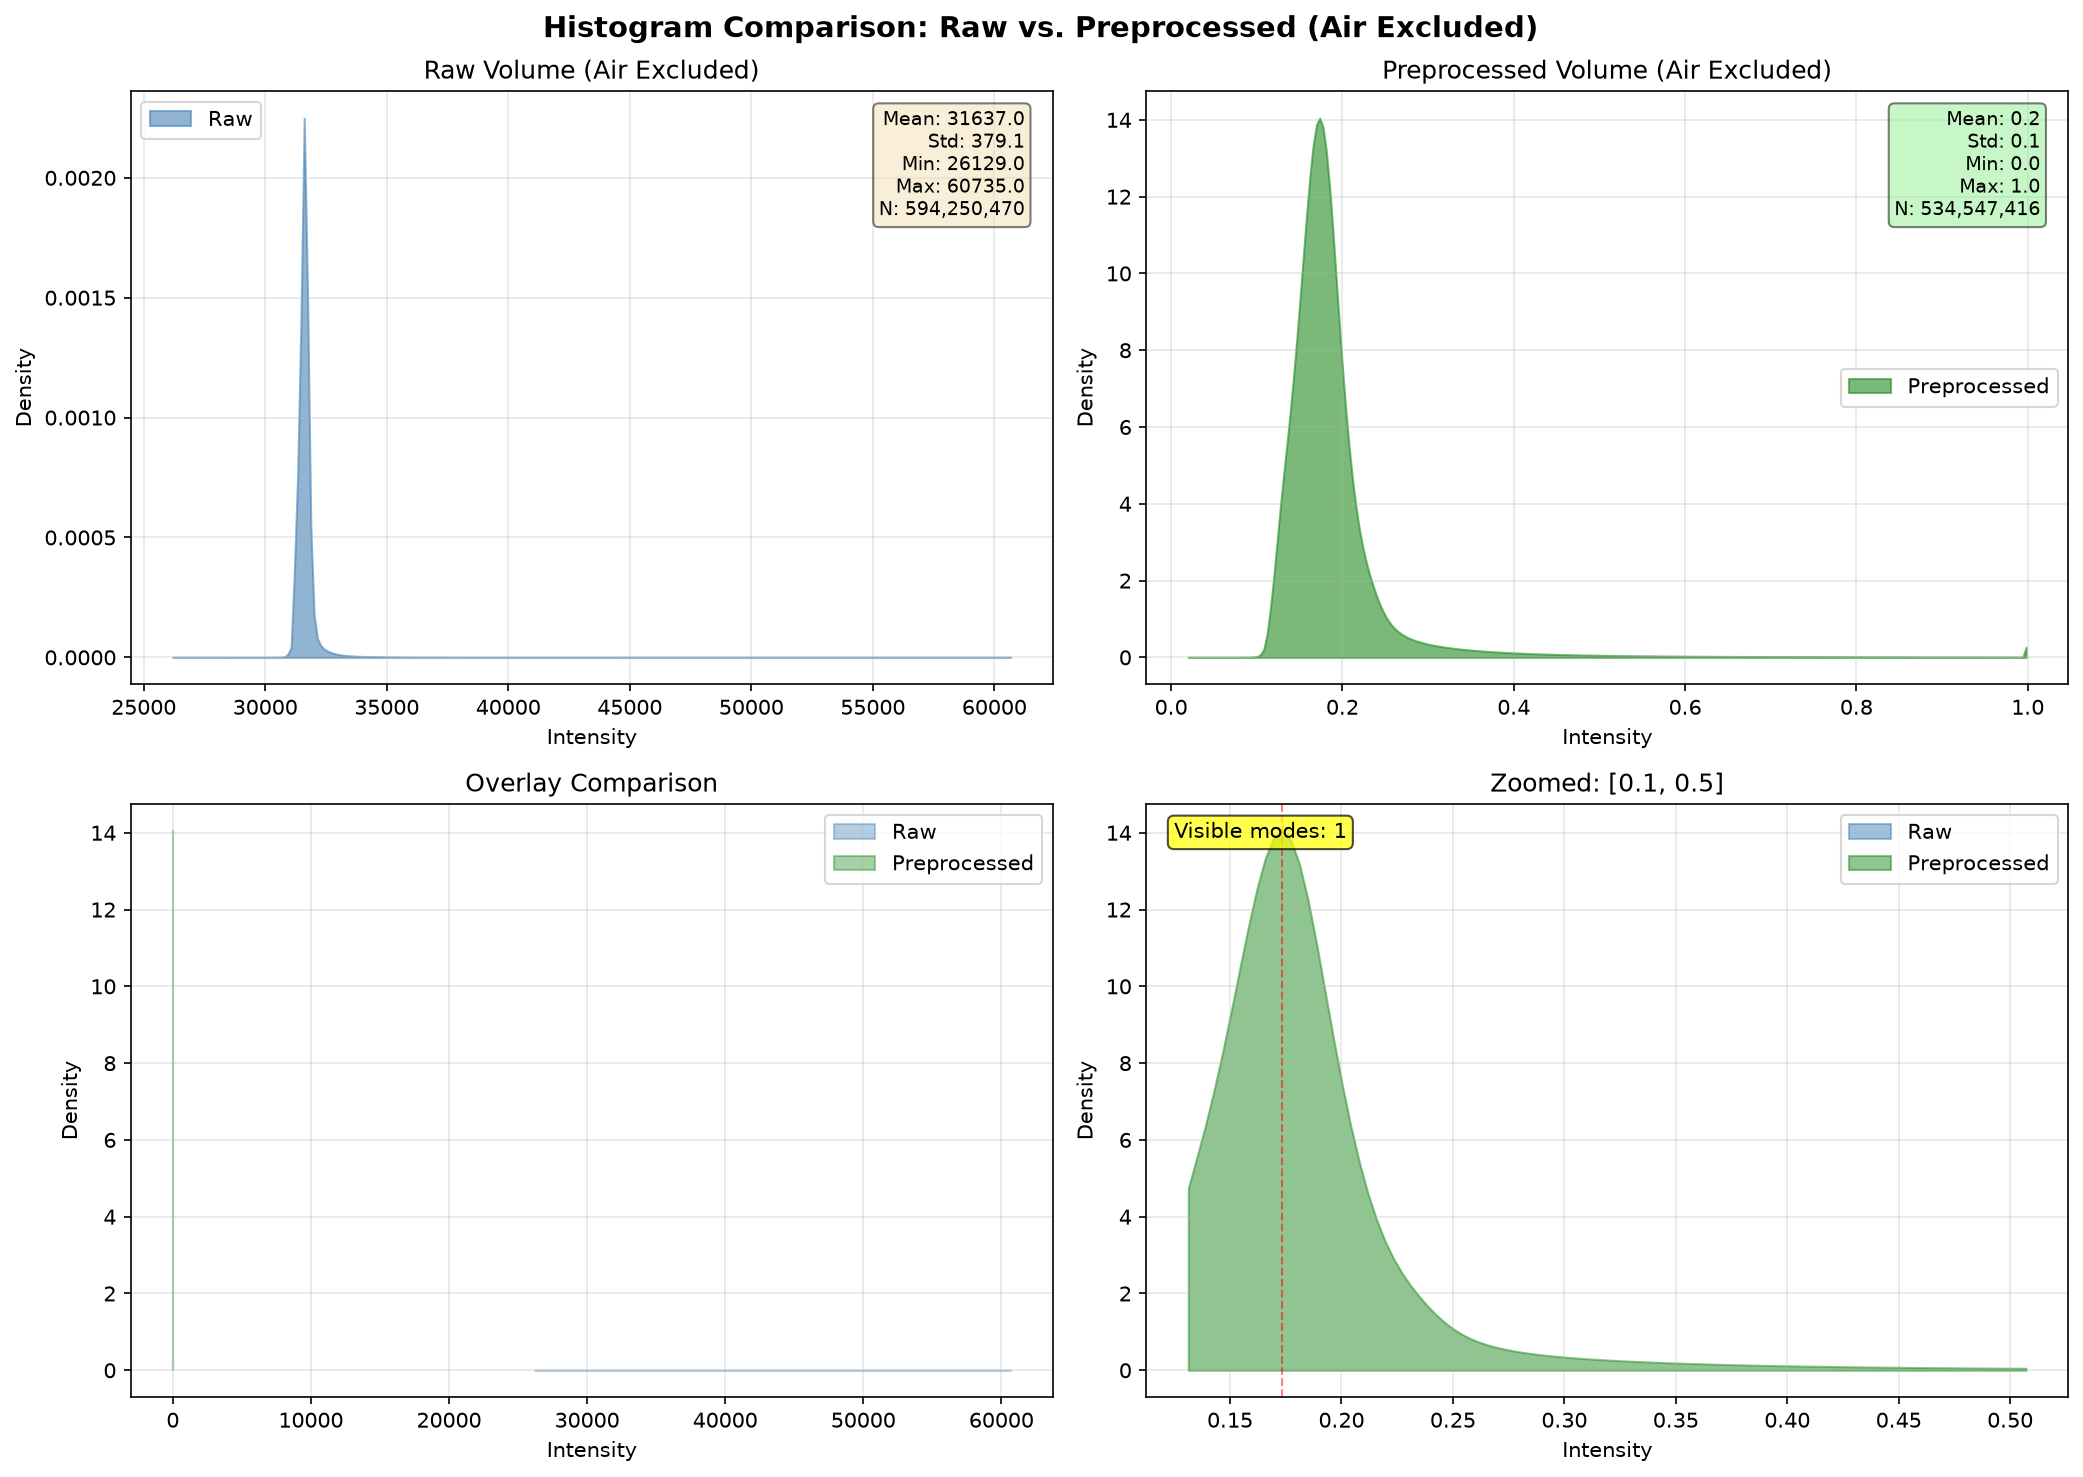


=== Raw Per-Slice Histograms ===


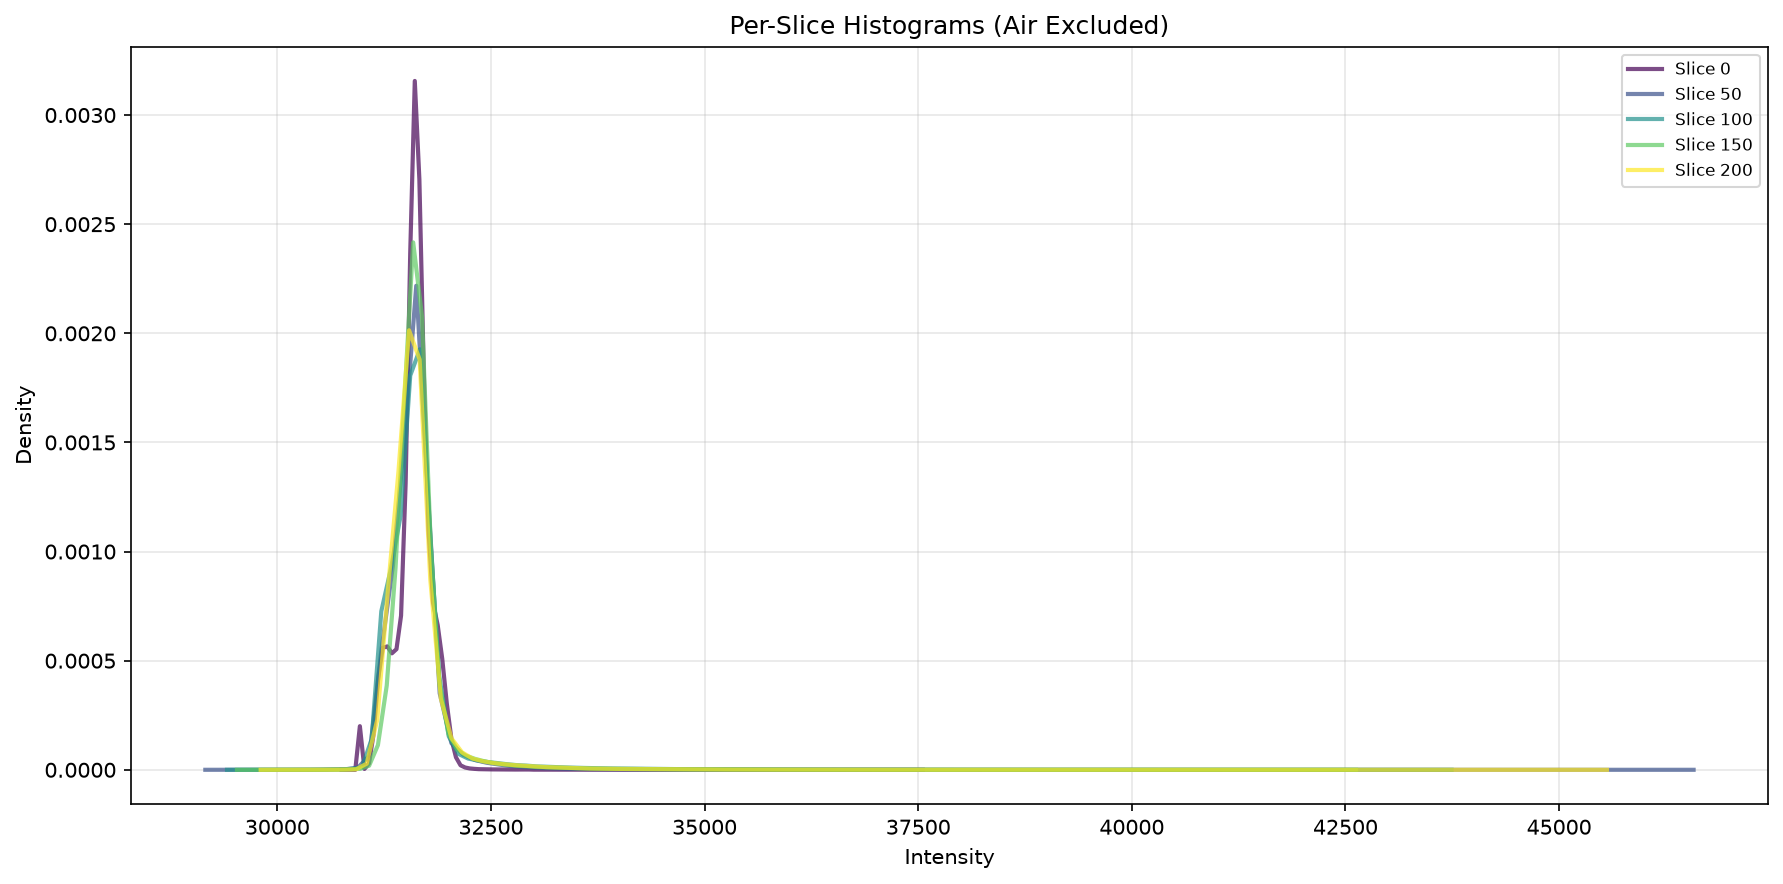


=== Processed Per-Slice Histograms ===


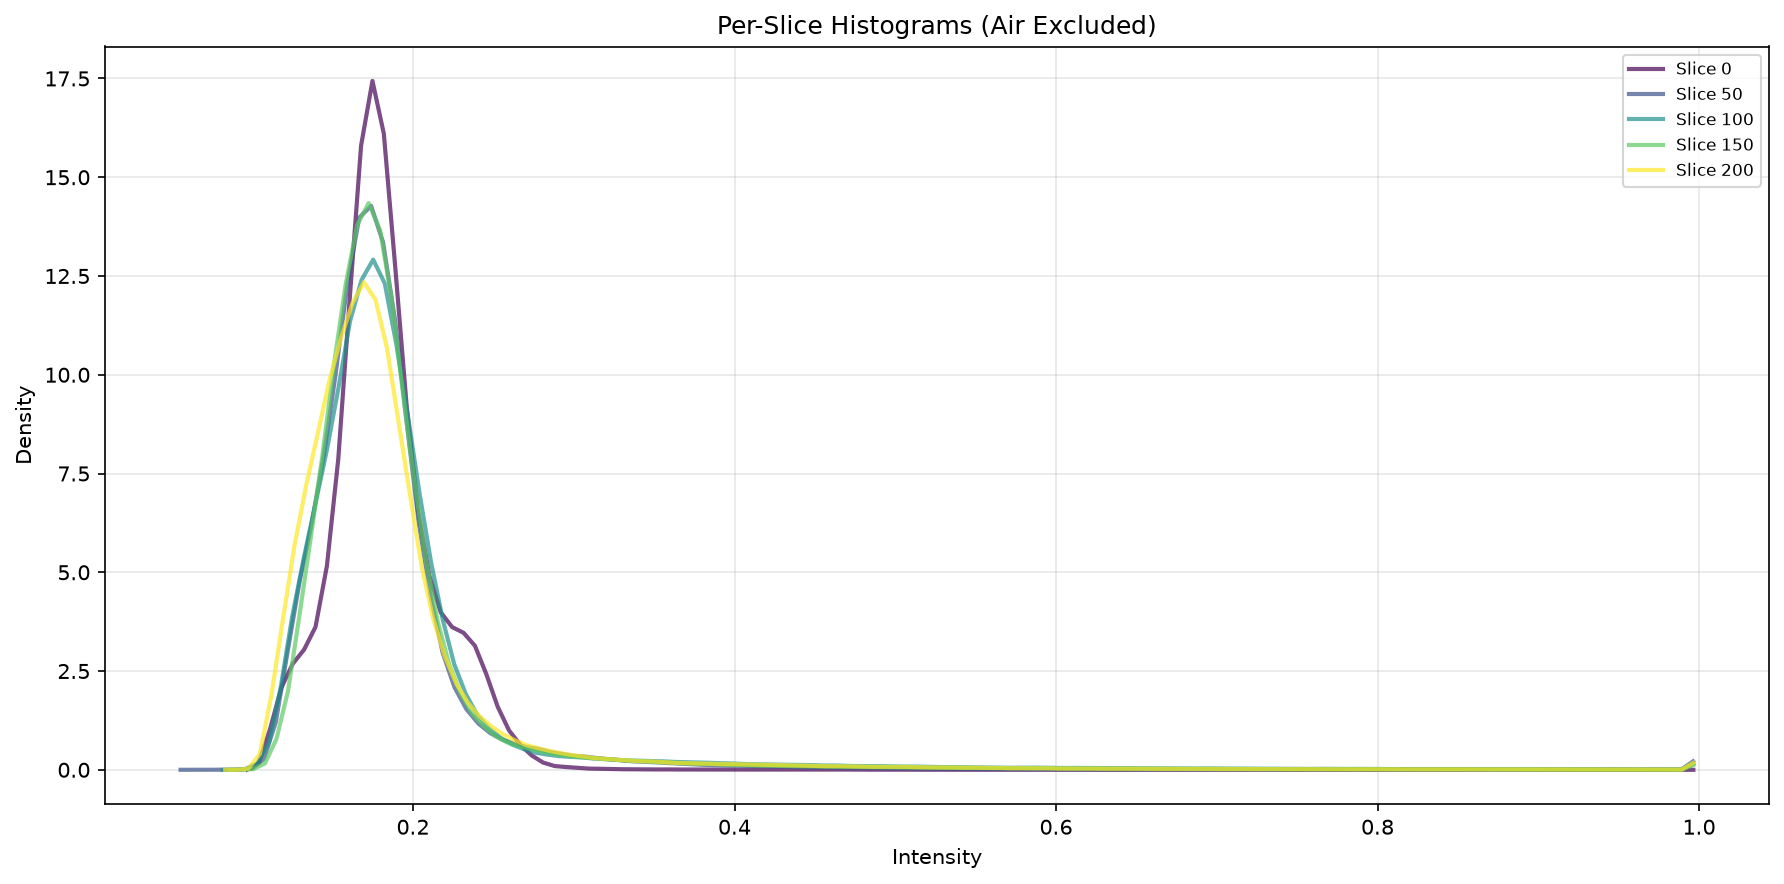

In [8]:
from IPython.display import Image, display

print("=== Before/After Histogram Comparison ===")
display(Image(filename=FIGURES_DIR / "histogram_before_after.png"))

print("\n=== Raw Per-Slice Histograms ===")
display(Image(filename=FIGURES_DIR / "histogram_per_slice_raw.png"))

print("\n=== Processed Per-Slice Histograms ===")
display(Image(filename=FIGURES_DIR / "histogram_per_slice_processed.png"))

## Inspect Diagnostics

Edge strength profile and page peak detection.

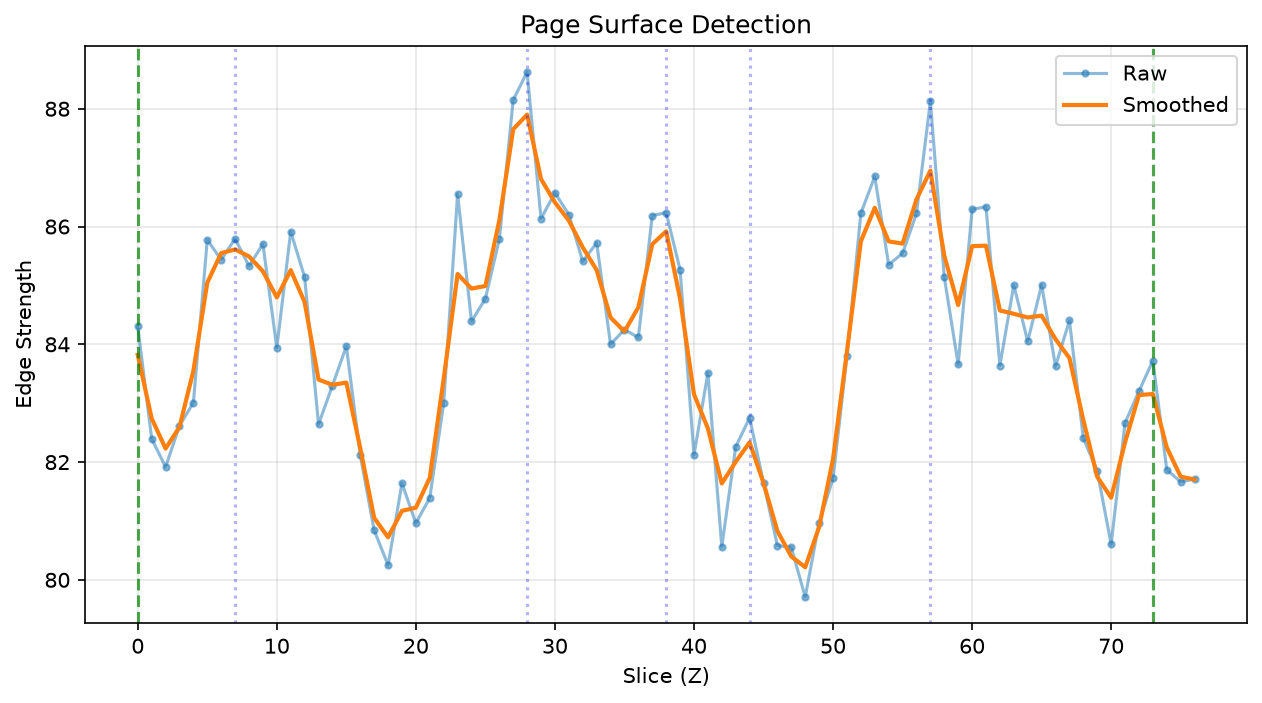

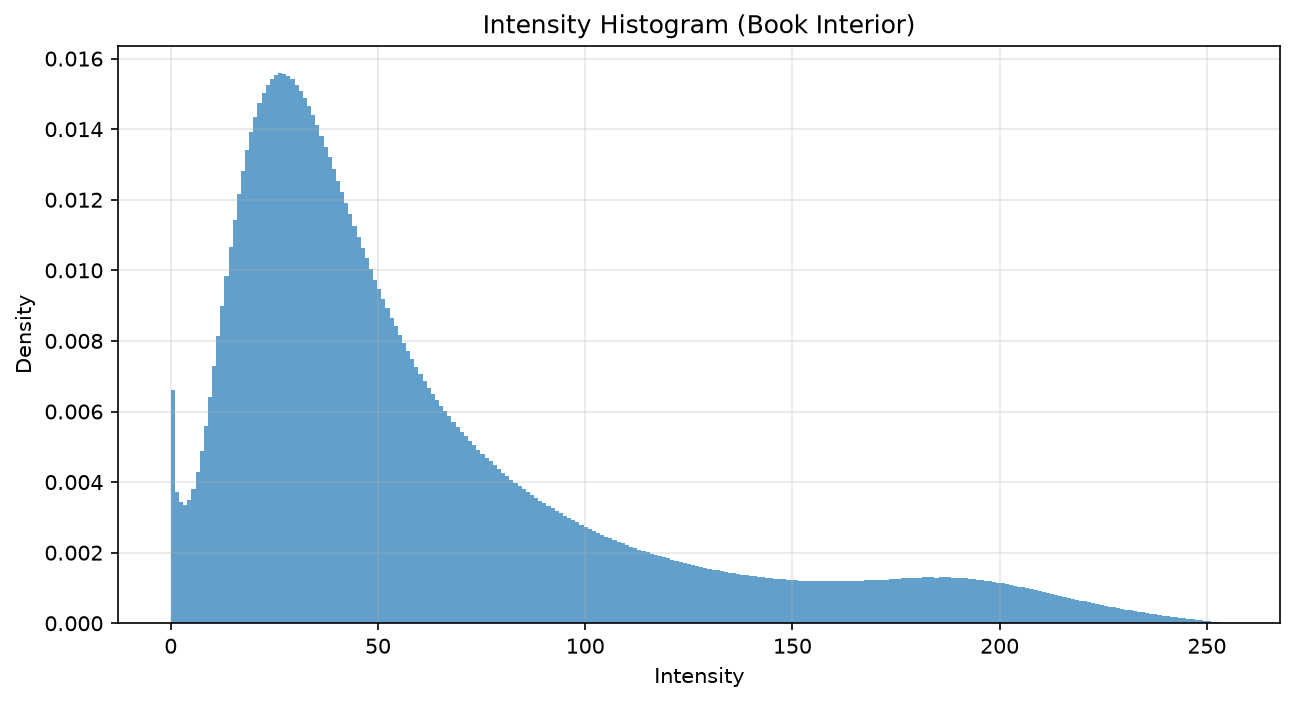

In [9]:
from IPython.display import Image, display

# Display saved diagnostic plots


if (DIAG_DIR / "edge_strength.png").exists():
    display(Image(DIAG_DIR / "edge_strength.png"))
if (DIAG_DIR / "histogram.png").exists():
    display(Image(DIAG_DIR / "histogram.png"))

## Compare Raw vs Processed

Visualize the effect of preprocessing on representative slices.

In [10]:
D = Volume.shape[0]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, z in enumerate([D//4, D//2, 3*D//4]):
    # Raw
    axes[0, i].imshow(Volume[z], cmap='gray')
    axes[0, i].set_title(f'Raw — Z={z}')
    axes[0, i].axis('off')
    
    # Processed
    axes[1, i].imshow(Processed_Volume[z], cmap='gray')
    axes[1, i].set_title(f'Processed — Z={z}')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Raw', fontsize=12)
axes[1, 0].set_ylabel('Processed', fontsize=12)
plt.suptitle('Preprocessing Comparison', fontsize=14)
plt.tight_layout()
plt.show()

plt.savefig(FIGURES_DIR / "Preprocessing Comparison.png", dpi=300, bbox_inches="tight")
plt.close()

C:\Users\ORSAdmin\AppData\Local\Temp\ipykernel_26360\990713693.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Histogram Comparison

Check if preprocessing improved separability.

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(Volume.ravel(), bins=256, density=True, alpha=0.7, color='gray')
axes[0].set_title('Raw Intensity Histogram')
axes[0].set_xlabel('Intensity')
axes[0].set_ylabel('Density')
axes[0].grid(True, alpha=0.3)

axes[1].hist(Processed_Volume.ravel(), bins=256, density=True, alpha=0.7, color="steelblue")
axes[1].set_title('Processed Intensity Histogram')
axes[1].set_xlabel('Intensity')
axes[1].set_ylabel('Density')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.savefig(FIGURES_DIR / "Processed Intensity Histogram.png", dpi=300, bbox_inches="tight")
plt.close()

C:\Users\ORSAdmin\AppData\Local\Temp\ipykernel_26360\4207188137.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Save Processed Volume

Store for next step (GMM fitting).

In [12]:
from research_ct.io.volume_saver import Save_As_Numpy

PROCESSED_DATA_DIR = OUTPUT_DATA_DIR / "processed"
PROCESSED_DATA_DIR.mkdir(exist_ok=True)

Save_As_Numpy(
    Processed_Volume,
    PROCESSED_DATA_DIR / "preprocessed_volume.npz",
)
print(f"Saved to {PROCESSED_DATA_DIR / 'preprocessed_volume.npz'}")

[Save_As_Numpy] Saved -> c:\Users\ORSAdmin\Documents\Gabriel\research_ct\data\output\processed\preprocessed_volume.npz
Saved to c:\Users\ORSAdmin\Documents\Gabriel\research_ct\data\output\processed\preprocessed_volume.npz
